In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [2]:
df = pd.read_csv("amazon_products_sales_data_cleaned.csv")

### Objetivo

Analizar qué factores influyen en el rendimiento de los productos tecnológicos en Amazon, evaluando el impacto de variables como la confianza del consumidor, la popularidad, el precio y las estrategias de visibilidad.

### Limpieza de Datos

#### Visualizar info de la tabla

In [3]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42675 entries, 0 to 42674
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   product_title         42675 non-null  object 
 1   product_rating        41651 non-null  float64
 2   total_reviews         41651 non-null  float64
 3   purchased_last_month  32164 non-null  float64
 4   discounted_price      40613 non-null  float64
 5   original_price        40613 non-null  float64
 6   is_best_seller        42675 non-null  object 
 7   is_sponsored          42675 non-null  object 
 8   has_coupon            42675 non-null  object 
 9   buy_box_availability  28022 non-null  object 
 10  delivery_date         30692 non-null  object 
 11  sustainability_tags   3408 non-null   object 
 12  product_image_url     42675 non-null  object 
 13  product_page_url      40606 non-null  object 
 14  data_collected_at     42675 non-null  object 
 15  product_category   

,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,discount_percentage
count,41651.000000,41651.000000,32164.000000,40613.000000,40613.000000,40613.000000
mean,4.399431,3087.106000,1293.665278,243.227289,257.611107,6.547151
std,0.386997,13030.460133,6318.323574,473.351545,496.633495,12.744715
min,1.000000,1.000000,50.000000,2.160000,2.160000,0.000000
25%,4.200000,82.000000,100.000000,29.690000,32.990000,0.000000
50%,4.500000,343.000000,200.000000,84.990000,89.000000,0.000000
75%,4.700000,1886.000000,400.000000,224.000000,229.990000,8.490000
max,5.000000,865598.000000,100000.000000,5449.000000,5449.000000,85.420000


In [4]:
df.head(5)

,product_title,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,is_best_seller,is_sponsored,has_coupon,buy_box_availability,delivery_date,sustainability_tags,product_image_url,product_page_url,data_collected_at,product_category,discount_percentage
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375.0,300.0,89.68,159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,2025-09-01,Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Phones,43.60
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457.0,6000.0,9.99,15.99,No Badge,Sponsored,No Coupon,Add to cart,2025-08-29,NaN,https://m.media-amazon.com/images/I/61nbF6aVIP...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Laptops,37.52
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044.0,2000.0,314.00,349.00,No Badge,Sponsored,No Coupon,Add to cart,2025-09-01,NaN,https://m.media-amazon.com/images/I/61h78MEXoj...,https://www.amazon.com/sspa/click?ie=UTF8&spc=...,2025-08-21 11:14:29,Laptops,10.03
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",4.6,35882.0,10000.0,162.24,162.24,Best Seller,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61SUj2aKoE...,https://www.amazon.com/Apple-Cancellation-Tran...,2025-08-21 11:14:29,Phones,0.00
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,4.8,28988.0,10000.0,72.74,72.74,No Badge,Organic,No Coupon,NaN,NaN,NaN,https://m.media-amazon.com/images/I/61bMNCeAUA...,https://www.amazon.com/Apple-MX542LL-A-AirTag-...,2025-08-21 11:14:29,Phones,0.00


#### Normalizar nombres de columnas

In [5]:
def to_snake(s: str) -> str:
    s = s.strip() #Elimina espacios al inicio y al final
    s = re.sub(r"[^\w\s]", "", s) #"todo lo que NO sea letra, número o espacio" lo reemplazamos por "" (nada). Se eliminan símbolos raros.
    s = re.sub(r"\s+", "_", s) #\s+ → uno o más espacios se reemplazan por _
    return s.lower() #Convierte todo a minúsculas

df = df.rename(columns={c: to_snake(c) for c in df.columns}) #usa ese diccionario para renombrar todo
df.columns

Index(['product_title', 'product_rating', 'total_reviews',
       'purchased_last_month', 'discounted_price', 'original_price',
       'is_best_seller', 'is_sponsored', 'has_coupon', 'buy_box_availability',
       'delivery_date', 'sustainability_tags', 'product_image_url',
       'product_page_url', 'data_collected_at', 'product_category',
       'discount_percentage'],
      dtype='object')

#### Limpiar strings (espacios, “None”, vacíos)

In [6]:
STR_COLS = df.select_dtypes(include="object").columns.tolist() #Selecciona columnas tipo texto. Devuelve sus nombres. Convierte los nombres a lista. 

def clean_str(x): #Define una función para limpiar cada celda individual.
    if pd.isna(x): #Detectar nulos reales
        return np.nan #Si el valor ya es NaN, lo dejamos como NaN
    x = str(x).strip() #Convierte a string (por seguridad). Elimina espacios al inicio y final
    if x == "" or x.lower() in {"none", "null", "nan"}: #Convierte strings “falsos nulos” en NaN
        return np.nan
    # normaliza espacios múltiples
    x = re.sub(r"\s+", " ", x)
    return x

for c in STR_COLS:
    df[c] = df[c].map(clean_str) # Aplica la limpieza a todas las columnas

#### Convertir variables a formato correcto

In [7]:
df["data_collected_at"] = pd.to_datetime(df["data_collected_at"], errors="coerce").dt.date
df["delivery_date"] = pd.to_datetime(df["delivery_date"], errors="coerce")

#### Nulos 

In [8]:
na_pct = (df.isna().mean()*100).sort_values(ascending=False) #Calcula el % de valores nulos por columna y los muestra de mayor a menor.
na_pct.round(2)

sustainability_tags     92.01
buy_box_availability    34.34
delivery_date           28.08
purchased_last_month    24.63
product_page_url         4.85
discount_percentage      4.83
discounted_price         4.83
original_price           4.83
total_reviews            2.40
product_rating           2.40
product_category         0.00
data_collected_at        0.00
product_title            0.00
product_image_url        0.00
is_sponsored             0.00
is_best_seller           0.00
has_coupon               0.00
dtype: float64

##### Eliminamos las columnas que a simple vista serán irrelevantes para el análisis 

In [9]:
# sustainability_tags contiene un 92% de valores nulos. Decidimos eliminarla porque no hay forma de rellenar los nulos sin que se cesguen los datos.
# las columnas product_image_url y product_page_url no son representativas para el análisis.

df.drop(columns=["sustainability_tags", "product_image_url", "product_page_url"], axis=1, inplace=True)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42675 entries, 0 to 42674
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   product_title         42675 non-null  object        
 1   product_rating        41651 non-null  float64       
 2   total_reviews         41651 non-null  float64       
 3   purchased_last_month  32164 non-null  float64       
 4   discounted_price      40613 non-null  float64       
 5   original_price        40613 non-null  float64       
 6   is_best_seller        42675 non-null  object        
 7   is_sponsored          42675 non-null  object        
 8   has_coupon            42675 non-null  object        
 9   buy_box_availability  28022 non-null  object        
 10  delivery_date         30692 non-null  datetime64[ns]
 11  data_collected_at     42675 non-null  object        
 12  product_category      42675 non-null  object        
 13  discount_percent

##### Analizamos los valores duplicados exactos

In [11]:
df.duplicated().sum()

np.int64(32671)

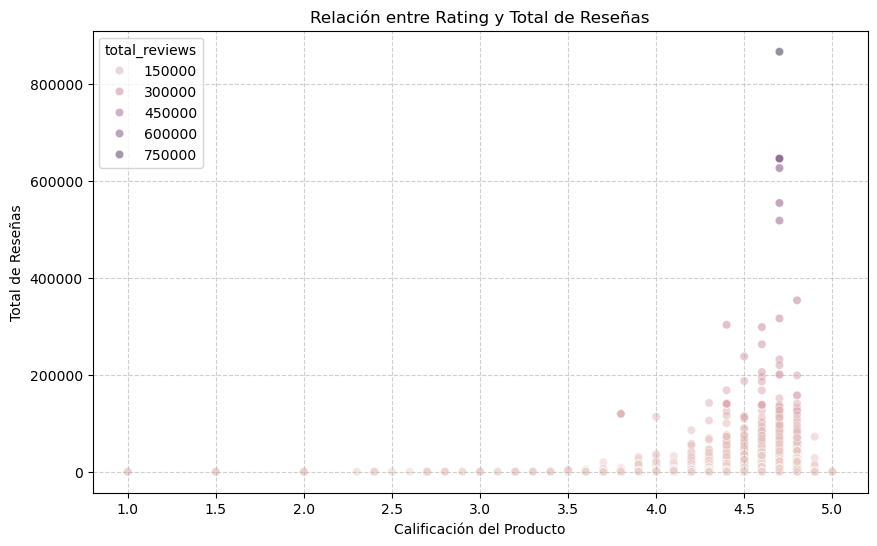

In [12]:
# Gráfico de dispersión product_rating vs total_reviews 
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data = df,
    x = 'product_rating', 
    y = 'total_reviews', 
    hue = 'total_reviews', 
    alpha=0.5)

plt.title('Relación entre Rating y Total de Reseñas')
plt.xlabel('Calificación del Producto')
plt.ylabel('Total de Reseñas')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [13]:
df.loc[
    df[["product_rating", "total_reviews"]].isnull().any(axis=1),
    ["product_category",'product_title', "product_rating", "total_reviews"]
]

,product_category,product_title,product_rating,total_reviews
854,Other Electronics,Buffalo Games - Gold - Eric Dowdle - Golden Ga...,NaN,NaN
1857,Laptops,"Lenovo ThinkPad X1 Carbon Gen 13 Aura Edition,...",NaN,NaN
2599,Cameras,FEELWORLD F7 Plus Camera Field Touchscreen Mon...,NaN,NaN
2600,Cameras,FEELWORLD P6XL Camera Field Touchscreen Monito...,NaN,NaN
3481,Cameras,FEELWORLD 4K10X PTZ Camera 4K Resolution 10X U...,NaN,NaN
...,...,...,...,...
42545,Laptops,acer 2-Pack Laptop Privacy Screen - for Laptop...,NaN,NaN
42587,Laptops,acer 2-Pack Laptop Privacy Screen - for Laptop...,NaN,NaN
42605,Laptops,GIGABYTE B860 Eagle WIFI6E Intel Core Ultra (S...,NaN,NaN
42629,Laptops,GIGABYTE B860 Eagle WIFI6E Intel Core Ultra (S...,NaN,NaN


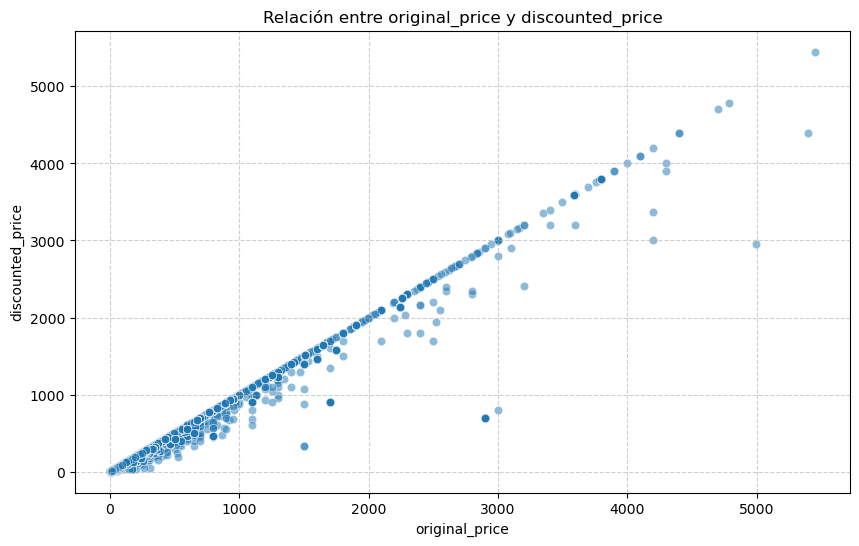

In [14]:
# Gráfico de dispersión discounted_price vs original_price 
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='original_price', y='discounted_price', alpha=0.5)

plt.title('Relación entre original_price y discounted_price')
plt.xlabel('original_price')
plt.ylabel('discounted_price')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [15]:
df.loc[
    df[['original_price', 'discounted_price', 'discount_percentage']].isnull().any(axis=1),
    ["product_category",'product_title', 'original_price', 'discounted_price', 'discount_percentage']
]

,product_category,product_title,original_price,discounted_price,discount_percentage
24,Power & Batteries,Duracell 2032 Lithium Battery. 4 Count Pack. C...,NaN,NaN,NaN
36,Power & Batteries,"Energizer Ultimate Lithium AA Batteries Pack, ...",NaN,NaN,NaN
123,Power & Batteries,Energizer Ultimate Lithium AA Batteries (8 Pac...,NaN,NaN,NaN
164,Phones,"Apple iPhone 12, 64GB, Black - Fully Unlocked ...",NaN,NaN,NaN
179,Phones,"Apple iPhone 14, 128GB, Midnight - Unlocked (R...",NaN,NaN,NaN
...,...,...,...,...,...
42567,Other Electronics,"Harman Kardon Onyx Studio 8 (Renewed), Black",NaN,NaN,NaN
42576,Laptops,Xbox Elite Wireless Controller Series 2 Core –...,NaN,NaN,NaN
42581,Phones,"Apple iPhone 12, 128GB, Blue - Boost Mobile (R...",NaN,NaN,NaN
42591,Phones,Samsung Galaxy Watch4 44MM SM-R870 Aluminum Sm...,NaN,NaN,NaN


##### Eliminamos filas con valores duplicados exactos que representan menos del 5%

In [16]:
df.isna().mean()*100

product_title            0.000000
product_rating           2.399531
total_reviews            2.399531
purchased_last_month    24.630346
discounted_price         4.831869
original_price           4.831869
is_best_seller           0.000000
is_sponsored             0.000000
has_coupon               0.000000
buy_box_availability    34.336262
delivery_date           28.079672
data_collected_at        0.000000
product_category         0.000000
discount_percentage      4.831869
dtype: float64

In [17]:
columnas_duplicados_exactos = ['product_rating', 'total_reviews', 'discounted_price', 'original_price', "discount_percentage"]

# Eliminamos filas donde CUALQUIERA de estas columnas sea nula
df = df.dropna(subset=columnas_duplicados_exactos)

##### Completamos nulos faltantes

##### purchased_last_month: mantenemos los valores para análisis posterior y los clasificamos en nueva columna de rango 

In [18]:
# 1. Definimos los límites de los rangos (bins)
# Ejemplo: 0-100 (C), 100-1000 (B), 1000 a infinito (A)
bins = [-1, 100, 1000, float('inf')]
labels = ['Rango C (Bajo)', 'Rango B (Medio)', 'Rango A (Alto)']

# 2. Creamos la nueva columna de categorías basada en 'purchased_lastmonth'
# Los nulos se mantendrán como nulos temporalmente en esta nueva columna
df['ventas_status'] = pd.cut(df['purchased_last_month'], bins=bins, labels=labels)

# 3. Convertimos la columna a tipo 'object' o 'category' para poder agregar la nueva etiqueta
df['ventas_status'] = df['ventas_status'].astype(object)

# 4. Rellenamos los nulos con "Rango D (Sin Datos)"
df['ventas_status'] = df['ventas_status'].fillna('Rango D (Sin Datos)')

# Verificamos cuántos productos cayeron en cada rango
print(df['ventas_status'].value_counts())

ventas_status
Rango B (Medio)        14713
Rango C (Bajo)         13202
Rango D (Sin Datos)     9362
Rango A (Alto)          2313
Name: count, dtype: int64


##### buy_box_availability: cambiamos las opciones a disponible / no disponible para completar valores NaN

In [19]:
#Completar valores NaN en buy_box_availability 

df["buy_box_availability"].unique()

array(['Add to cart', nan], dtype=object)

In [20]:
# 1. Primero, convertimos toda la columna a string y manejamos los nulos de una vez
df['buy_box_availability'] = df['buy_box_availability'].astype(str).fillna('nan')

# 2. Creamos una función sencilla para clasificar
def clasificar_disponibilidad(texto):
    if 'Add to cart' in texto:
        return 'disponible'
    else:
        return 'no disponible'

# 3. Aplicamos la función a toda la columna
df['buy_box_availability'] = df['buy_box_availability'].apply(clasificar_disponibilidad)

df.head(5)

,product_title,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,is_best_seller,is_sponsored,has_coupon,buy_box_availability,delivery_date,data_collected_at,product_category,discount_percentage,ventas_status
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375.0,300.0,89.68,159.00,No Badge,Sponsored,Save 15% with coupon,disponible,2025-09-01,2025-08-21,Phones,43.60,Rango B (Medio)
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457.0,6000.0,9.99,15.99,No Badge,Sponsored,No Coupon,disponible,2025-08-29,2025-08-21,Laptops,37.52,Rango A (Alto)
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044.0,2000.0,314.00,349.00,No Badge,Sponsored,No Coupon,disponible,2025-09-01,2025-08-21,Laptops,10.03,Rango A (Alto)
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",4.6,35882.0,10000.0,162.24,162.24,Best Seller,Organic,No Coupon,no disponible,NaT,2025-08-21,Phones,0.00,Rango A (Alto)
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,4.8,28988.0,10000.0,72.74,72.74,No Badge,Organic,No Coupon,no disponible,NaT,2025-08-21,Phones,0.00,Rango A (Alto)


##### delivery_date: rellenamos los nulos con una fecha muy lejana

In [21]:
df["delivery_date"].unique()

<DatetimeArray>
['2025-09-01 00:00:00', '2025-08-29 00:00:00',                 'NaT',
 '2025-09-04 00:00:00', '2025-09-08 00:00:00', '2025-08-28 00:00:00',
 '2025-09-09 00:00:00', '2025-09-02 00:00:00', '2025-09-03 00:00:00',
 '2025-09-22 00:00:00', '2025-08-27 00:00:00', '2025-09-05 00:00:00',
 '2025-09-10 00:00:00', '2025-09-15 00:00:00', '2025-09-16 00:00:00',
 '2025-09-17 00:00:00', '2025-09-19 00:00:00', '2025-09-12 00:00:00',
 '2025-09-11 00:00:00', '2025-08-30 00:00:00', '2025-09-06 00:00:00',
 '2025-09-29 00:00:00', '2025-09-23 00:00:00']
Length: 23, dtype: datetime64[ns]

In [22]:
# Aseguramos que sea formato datetime
df['delivery_date'] = pd.to_datetime(df['delivery_date'])

# Definimos una fecha muy lejana (ejemplo: año 2099 o 9999)
# Nota: Pandas soporta hasta el año 2262 en versiones estándar, 
# así que usaremos 2099-12-31 para evitar errores de "Out of Bounds"
fecha_lejana = pd.Timestamp('2099-12-31')

# Rellenamos los nulos
df['delivery_date'] = df['delivery_date'].fillna(fecha_lejana)

In [23]:
df.isna().mean()*100

product_title            0.000000
product_rating           0.000000
total_reviews            0.000000
purchased_last_month    23.647386
discounted_price         0.000000
original_price           0.000000
is_best_seller           0.000000
is_sponsored             0.000000
has_coupon               0.000000
buy_box_availability     0.000000
delivery_date            0.000000
data_collected_at        0.000000
product_category         0.000000
discount_percentage      0.000000
ventas_status            0.000000
dtype: float64

##### Vemos qué columnas nos quedan que no tengan los datos correctos, ambiguos o que necesiten un ajuste para el análisis posterior

In [24]:
# La columna discounted_price no corresponde al valor exacto entre la diferencia del valor original y el % de descuento aplicado. Al ser ambigua, preferimos eliminarla.
df.drop(columns =["discounted_price"], inplace = True)

##### Creamos una nueva columna facturación para analizar impacto económico real y no solo el volumen de ventas

In [25]:
# Hacemos una nueva columna con los datos reales de facturación

# Pasamos a 0 todos los valores nulos en la columna purchased_last_month

df["purchased_last_month"] = df["purchased_last_month"].fillna(0)

#Si no hay dato de ventas recientes lo más probable es que: No se vendió o se vendió muy poco.

In [26]:
# Limpiamos y convertimos original_price a float

df["original_price"] = (
    df["original_price"]
    .astype(str)
    .str.replace("$", "", regex=False) #Primero quitamos símbolos y comas
    .str.replace(",", "", regex=False)
)

In [27]:
df["original_price"] = pd.to_numeric(df["original_price"], errors="coerce") #Ahora convertimos a número

In [28]:
# Creamos columna facturación

df["facturación"] = df["purchased_last_month"] * df["original_price"]

In [29]:
# Para evitar NaNs en facturación.

df["purchased_last_month"] = df["purchased_last_month"].fillna(0)
df["original_price"] = df["original_price"].fillna(0)

In [30]:
df[["purchased_last_month", "original_price", "facturación"]]

,purchased_last_month,original_price,facturación
0,300.0,159.00,47700.0
1,6000.0,15.99,95940.0
2,2000.0,349.00,698000.0
3,10000.0,162.24,1622400.0
4,10000.0,72.74,727400.0
...,...,...,...
42670,100.0,195.99,19599.0
42671,200.0,89.99,17998.0
42672,50.0,1099.99,54999.5
42673,500.0,15.98,7990.0


In [31]:
df.head(5)

,product_title,product_rating,total_reviews,purchased_last_month,original_price,is_best_seller,is_sponsored,has_coupon,buy_box_availability,delivery_date,data_collected_at,product_category,discount_percentage,ventas_status,facturación
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375.0,300.0,159.00,No Badge,Sponsored,Save 15% with coupon,disponible,2025-09-01,2025-08-21,Phones,43.60,Rango B (Medio),47700.0
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457.0,6000.0,15.99,No Badge,Sponsored,No Coupon,disponible,2025-08-29,2025-08-21,Laptops,37.52,Rango A (Alto),95940.0
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044.0,2000.0,349.00,No Badge,Sponsored,No Coupon,disponible,2025-09-01,2025-08-21,Laptops,10.03,Rango A (Alto),698000.0
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",4.6,35882.0,10000.0,162.24,Best Seller,Organic,No Coupon,no disponible,2099-12-31,2025-08-21,Phones,0.00,Rango A (Alto),1622400.0
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,4.8,28988.0,10000.0,72.74,No Badge,Organic,No Coupon,no disponible,2099-12-31,2025-08-21,Phones,0.00,Rango A (Alto),727400.0


### Análisis Exploratorio

#### A) Análisis por venta y facturación (¿Qué hace que un producto venda más?)

##### Rating vs Ventas

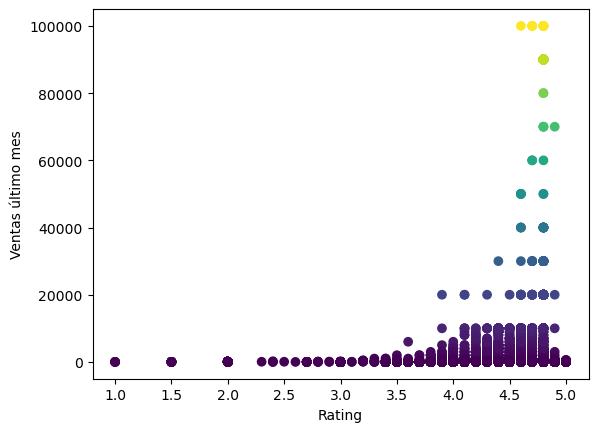

In [32]:
plt.scatter(df["product_rating"], df["purchased_last_month"], c=df["purchased_last_month"], cmap='viridis')
plt.xlabel("Rating")
plt.ylabel("Ventas último mes")
plt.show()

##### Rating vs Facturación

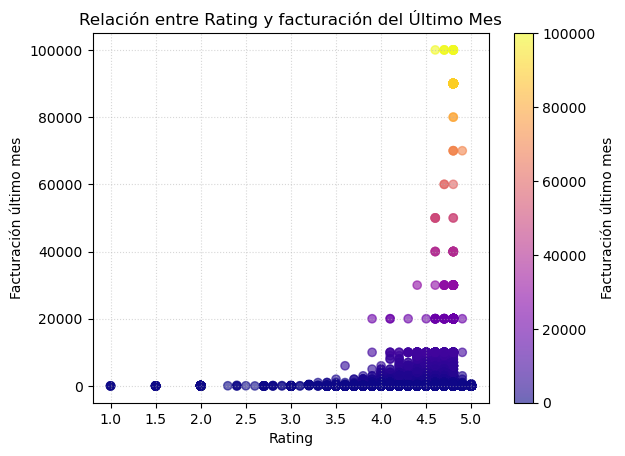

In [33]:
scatter = plt.scatter(
    df["product_rating"], 
    df["purchased_last_month"], 
    c = df["purchased_last_month"], 
    cmap = 'plasma', 
    alpha = 0.6
)

plt.colorbar(scatter, label = 'Facturación último mes')

plt.xlabel("Rating")
plt.ylabel("Facturación último mes")
plt.title("Relación entre Rating y facturación del Último Mes")
plt.grid(True, linestyle = ':', alpha = 0.5)

plt.show()

##### Reviews vs Ventas

C:\Users\Abrah\AppData\Local\Temp\ipykernel_38160\550285845.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  revenue_reviews = df.groupby("review_group")["purchased_last_month"].mean()


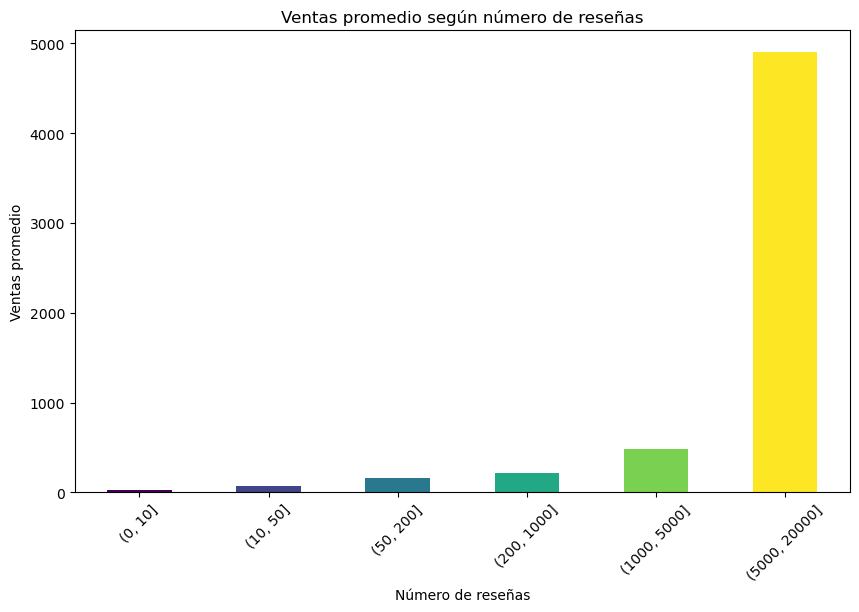

In [34]:
bins = [0,10,50,200,1000,5000,20000]
df["review_group"] = pd.cut(df["total_reviews"], bins)

revenue_reviews = df.groupby("review_group")["purchased_last_month"].mean()

revenue_reviews.plot(kind="bar", figsize=(10,6), color=plt.cm.viridis(np.linspace(0, 1, len(revenue_reviews))))

plt.title("Ventas promedio según número de reseñas")
plt.xlabel("Número de reseñas")
plt.ylabel("Ventas promedio")
plt.xticks(rotation = 45)

plt.show()

##### Reviews vs Facturación

C:\Users\Abrah\AppData\Local\Temp\ipykernel_38160\873146680.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  revenue_reviews = df.groupby("review_group")["facturación"].mean()


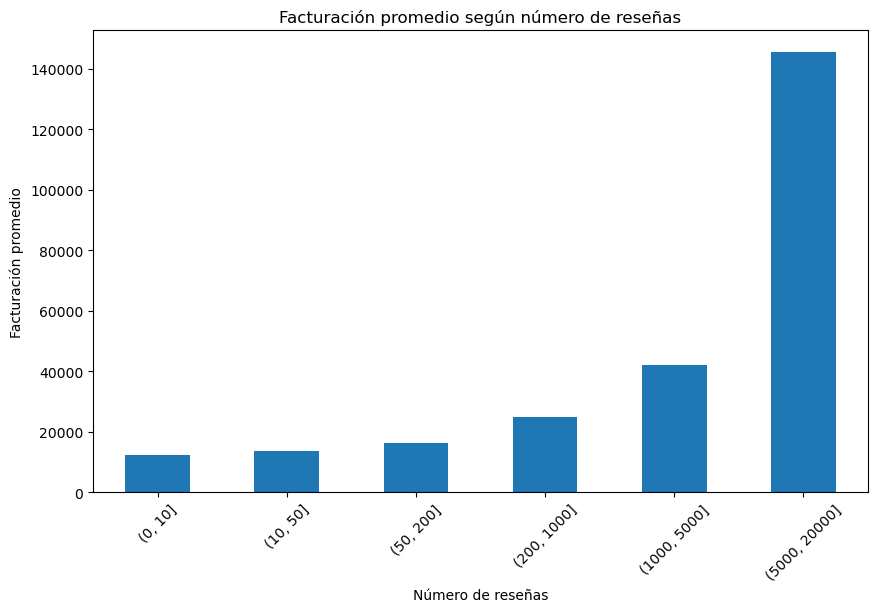

In [35]:
bins = [0,10,50,200,1000,5000,20000]
df["review_group"] = pd.cut(df["total_reviews"], bins)

revenue_reviews = df.groupby("review_group")["facturación"].mean()

revenue_reviews.plot(kind="bar", figsize=(10,6))

plt.title("Facturación promedio según número de reseñas")
plt.xlabel("Número de reseñas")
plt.ylabel("Facturación promedio")
plt.xticks(rotation=45)

plt.show()

C:\Users\Abrah\AppData\Local\Temp\ipykernel_38160\1416475464.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  revenue_reviews = df.groupby("review_group")["facturación"].mean().iloc[:-2]


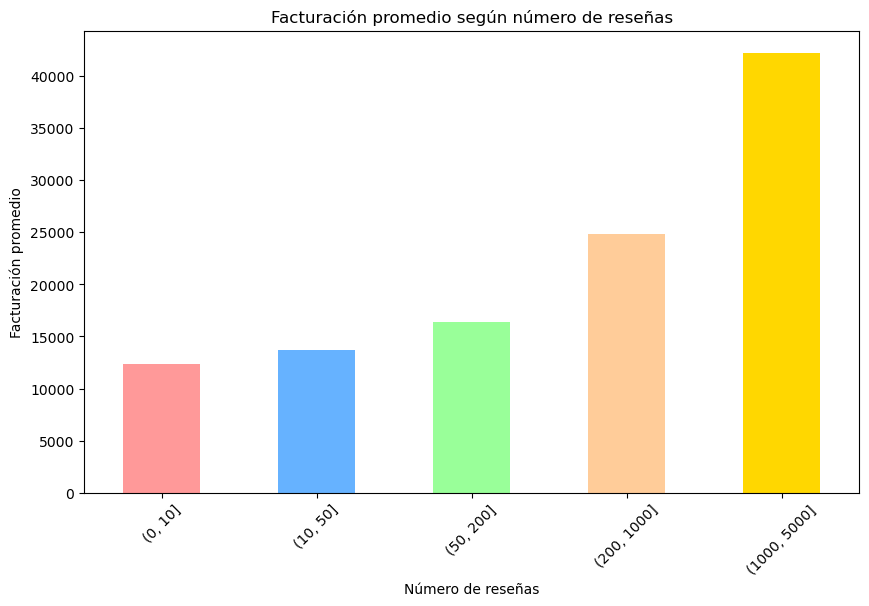

In [36]:
#sugerencia de Nacho

bins = [0,10,50,200,1000,5000,20000,1000000]

df["review_group"] = pd.cut(df["total_reviews"], bins)

revenue_reviews = df.groupby("review_group")["facturación"].mean().iloc[:-2]

revenue_reviews.plot(kind="bar", figsize=(10,6), color=['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#FFD700', '#DA70D6', '#40E0D0'])

plt.title("Facturación promedio según número de reseñas")
plt.xlabel("Número de reseñas")
plt.ylabel("Facturación promedio")
plt.xticks(rotation=45)

plt.show()

C:\Users\Abrah\AppData\Local\Temp\ipykernel_38160\203382714.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  revenue_reviews = df.groupby("review_group")["facturación"].sum()


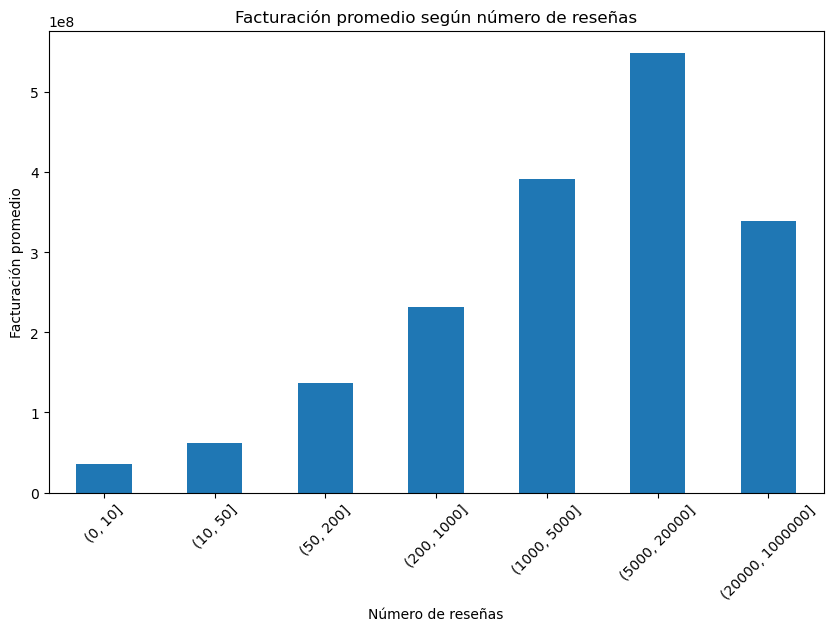

In [37]:
bins = [0,10,50,200,1000,5000,20000,1000000]

df["review_group"] = pd.cut(df["total_reviews"], bins)

revenue_reviews = df.groupby("review_group")["facturación"].sum()

revenue_reviews.plot(kind="bar", figsize=(10,6))

plt.title("Facturación promedio según número de reseñas")
plt.xlabel("Número de reseñas")
plt.ylabel("Facturación promedio")
plt.xticks(rotation=45)

plt.show()

##### Descuento vs Ventas

In [38]:
# usar bins para definir rangos de descuento
bins = [0,10,30,50,100]
df["discount_group"] = pd.cut(df["discount_percentage"], bins) #toma la columna discount_percentage y mete cada producto dentro del rango que le corresponde.

df.groupby("discount_group")["purchased_last_month"].mean() #Para cada grupo de descuento, calcula el promedio de ventas del último mes.

#clasificamos productos en:
    # Descuento bajo
    #Descuento medio
    #Descuento alto
    #Descuento agresivo

C:\Users\Abrah\AppData\Local\Temp\ipykernel_38160\4227942156.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("discount_group")["purchased_last_month"].mean() #Para cada grupo de descuento, calcula el promedio de ventas del último mes.


discount_group
(0, 10]       295.191364
(10, 30]     3112.338523
(30, 50]     1158.821035
(50, 100]     403.711790
Name: purchased_last_month, dtype: float64

C:\Users\Abrah\AppData\Local\Temp\ipykernel_38160\3208398860.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("discount_group")["purchased_last_month"].mean().plot(kind="bar", figsize=(10, 6), color=plt.cm.Paired.colors)


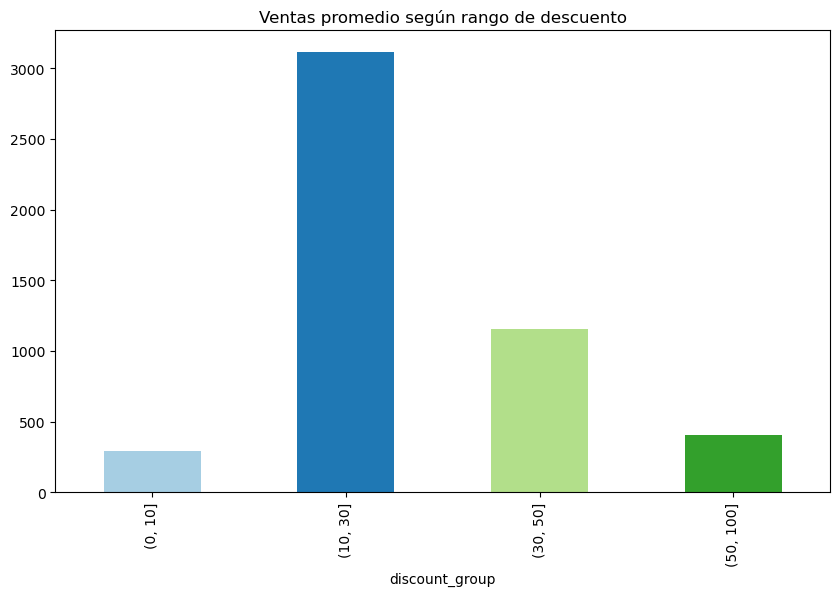

In [39]:
df.groupby("discount_group")["purchased_last_month"].mean().plot(kind="bar", figsize=(10, 6), color=plt.cm.Paired.colors)
plt.title("Ventas promedio según rango de descuento")
plt.show()

##### Descuento vs Facturación

In [40]:
# usar bins para definir rangos de descuento
bins = [0,10,30,50,100]
df["discount_group"] = pd.cut(df["discount_percentage"], bins) #toma la columna discount_percentage y mete cada producto dentro del rango que le corresponde.

df.groupby("discount_group")["facturación"].mean() #Para cada grupo de descuento, calcula el promedio de ventas del último mes.

#clasificamos productos en:
    # Descuento bajo
    #Descuento medio
    #Descuento alto
    #Descuento agresivo

C:\Users\Abrah\AppData\Local\Temp\ipykernel_38160\1847975.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("discount_group")["facturación"].mean() #Para cada grupo de descuento, calcula el promedio de ventas del último mes.


discount_group
(0, 10]      22412.351488
(10, 30]     97327.077840
(30, 50]     50875.394826
(50, 100]    38657.050946
Name: facturación, dtype: float64

C:\Users\Abrah\AppData\Local\Temp\ipykernel_38160\2158800010.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("discount_group")["facturación"].mean().plot(kind="bar")


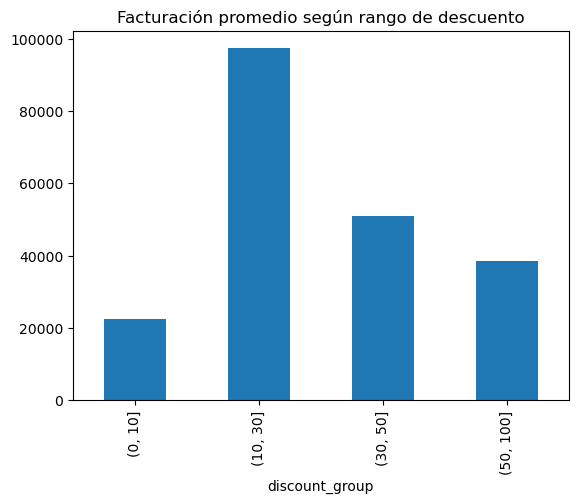

In [41]:
df.groupby("discount_group")["facturación"].mean().plot(kind="bar")
plt.title("Facturación promedio según rango de descuento")
plt.show()

##### Sponsored vs Orgánico

In [42]:
# Convertimos texto a 0 y 1 para el análisis
df["is_sponsored_flag"] = df["is_sponsored"].str.contains("Sponsored", na=False).astype(int)

In [43]:
# Sponsored vs Orgánico (ventas)
sales_sponsored_ventas = df.groupby("is_sponsored_flag")["purchased_last_month"].mean() # Agrupa los productos en dos grupos: orgánicos y sponsored y calcula el promedio de ventas del último mes Para cada grupo
sales_sponsored_ventas

is_sponsored_flag
0     403.664055
1    4151.020715
Name: purchased_last_month, dtype: float64

In [44]:
# Sponsored vs Orgánico (facturación)
sales_sponsored_facturacion = df.groupby("is_sponsored_flag")["facturación"].mean() # Agrupa los productos en dos grupos: orgánicos y sponsored y calcula el promedio de ventas del último mes Para cada grupo
sales_sponsored_facturacion

is_sponsored_flag
0     30103.013074
1    113476.532122
Name: facturación, dtype: float64

In [45]:
import matplotlib.pyplot as plt
import numpy as np

# Tu lógica de filtrado y bindeo
subset = df[
    (df["is_sponsored_flag"] == 1) &
    (df["trust_group"].isin(["Alta","Muy alta"]))
].copy()

bins = [0, 3.5, 4.0, 4.5, 5.0]
subset["rating_bin"] = pd.cut(subset["product_rating"], bins=bins, include_lowest=True)

rating_counts = subset["rating_bin"].value_counts().sort_index()

# Configuración del gráfico
plt.figure(figsize=(10, 6), facecolor='white')

# Paleta Profesional: Tonos neutros para ratings bajos y un verde vibrante para el top (4.5-5.0)
# Esto guía el ojo hacia los productos de mayor calidad.
colores_rating = ['#94a3b8', '#64748b', '#334155', '#10b981']

rating_counts.plot(kind="bar", color=colores_rating, width=0.7, edgecolor='white', linewidth=1)

# Estética y Títulos
plt.title("Sponsored con Trust Alto: Distribución de Ratings", fontsize=14, pad=20, fontweight='bold', color='#1e293b')
plt.xlabel("Rango de Rating", fontsize=11, color='#475569', labelpad=10)
plt.ylabel("Número de Productos", fontsize=11, color='#475569', labelpad=10)

# Limpieza visual: Estilo moderno sin marcos innecesarios
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_color('#e2e8f0')
plt.gca().spines['bottom'].set_color('#e2e8f0')

plt.xticks(rotation=0, color='#1e293b')
plt.yticks(color='#64748b')

# Opcional: Añadir el valor exacto sobre cada barra para máxima claridad
for i, v in enumerate(rating_counts):
    plt.text(i, v + (max(rating_counts) * 0.01), str(v), ha='center', fontsize=10, color='#334155', fontweight='bold')

plt.tight_layout()
plt.show()

KeyError: 'trust_group'

In [ ]:
sales_sponsored_ventas.plot(kind="bar", color=['skyblue', 'salmon'], figsize=(8, 6))

plt.xticks([0,1], ["Orgánico", "Sponsored"], rotation=0)
plt.title("Impacto de la publicidad en Ventas")
plt.ylabel("Ventas promedio último mes")

plt.show()

In [ ]:
sales_sponsored_facturacion.plot(kind="bar")

plt.xticks([0,1], ["Orgánico", "Sponsored"], rotation=0)
plt.title("Impacto de la Publicidad en Ventas")
plt.ylabel("Facturación promedio último mes")

plt.show()

##### Best Seller

In [ ]:
df["is_best_seller"].unique()

In [ ]:
# Ver todas las “opciones” reales dentro de is_best_seller
df["is_best_seller"].value_counts(dropna=False)

In [ ]:
df["has_badge"] = df["is_best_seller"].replace({
    "Amazon's": "con etiqueta",
    "Limited time deal": "con etiqueta",
    "Best Seller": "con etiqueta",
    "Save 30%": "con etiqueta",
    "Ends in": "con etiqueta",
    "Save 10%": "con etiqueta",
    "Save 18%": "con etiqueta",
    "Save 17%": "con etiqueta",
    "Save 12%": "con etiqueta",
    "Save 9%": "con etiqueta",
    "Save 77%": "con etiqueta",
    "No Badge": "sin etiqueta"
})

In [ ]:
df["has_badge"].value_counts()

In [ ]:
df[["is_best_seller", "has_badge"]]

In [ ]:
# Agrupar por etiqueta y calcular ventas promedio
sales_by_badge = (
    df
    .groupby("has_badge")["purchased_last_month"]
    .mean()
)

# Graficar
plt.figure(figsize=(8, 6))
sales_by_badge.plot(kind="bar", color=['lightblue', 'gold'])

plt.title("Ventas promedio según etiqueta", fontsize=14)
plt.xlabel("Tipo de etiqueta")
plt.ylabel("Ventas promedio último mes")

plt.xticks(rotation=0)
plt.show()

In [ ]:
# Agrupar por etiqueta y calcular ventas promedio
sales_by_badge = (
    df
    .groupby("has_badge")["facturación"]
    .mean()
)

# Graficar
plt.figure()
sales_by_badge.plot(kind="bar")

plt.title("Facturación promedio según etiqueta")
plt.xlabel("Tipo de etiqueta")
plt.ylabel("Facturación promedio último mes")

plt.xticks(rotation=0)
plt.show()

In [ ]:
# Comparación completa (ventas + rating + reviews) por tipo
summary = df.groupby("has_badge").agg(
    n_products=("has_badge", "size"),
    mean_sales=("purchased_last_month", "mean"),
    mean_rating=("product_rating", "mean"),
    mean_reviews=("total_reviews", "mean"),
).sort_values("mean_sales", ascending=False)

print(summary)

In [ ]:
# Comparación completa (facturación + rating + reviews) por tipo
summary = df.groupby("has_badge").agg(
    n_products=("has_badge", "size"),
    mean_sales=("facturación", "mean"),
    mean_rating=("product_rating", "mean"),
    mean_reviews=("total_reviews", "mean"),
).sort_values("mean_sales", ascending=False)

print(summary)

##### Has Coupon

In [ ]:
df["has_coupon"].unique()

In [ ]:
# Convertir texto a número decimal

import re
import numpy as np

df["has_coupon"] = df["has_coupon"].astype(str).str.lower()

#Extraer porcentaje
def extract_coupon(x):
    if pd.isna(x):
        return 0
    
    # Buscar porcentaje
    pct = re.search(r"(\d+(\.\d+)?)\s*%", x)
    if pct:
        return float(pct.group(1)) / 100  # convertir a decimal
    
    # Buscar valor en dólares
    money = re.search(r"\$(\d+(\.\d+)?)", x)
    if money:
        return float(money.group(1))  # dejamos el valor
    
    return 0

df["coupon_value"] = df["has_coupon"].apply(extract_coupon)

In [ ]:
# Clasificar tipos de cupón

# Crear tipo de cupón

def coupon_type(x):
    if "%" in x:
        return "Cupón %"
    elif "$" in x:
        return "Cupón $"
    elif x == "nan" or x.strip() == "":
        return "No coupon"
    else:
        return "Sin cupón"

df["coupon_type"] = df["has_coupon"].apply(coupon_type)

In [ ]:
# Ver el peso de cada tipo

#Conteo de productos por tipo

coupon_counts = df["coupon_type"].value_counts()

coupon_counts.plot(kind="bar", figsize=(10, 6), color=plt.cm.Set2.colors)
plt.grid(False)
plt.title("Distribución de tipos de cupón", fontsize=14, fontweight='bold')
plt.ylabel("Número de productos")
plt.xticks(rotation=0)
plt.show()

In [ ]:
df.head(5)

In [ ]:
# Impacto en ventas
# ¿Qué tipo de cupón factura más?
sales_coupon = df.groupby("coupon_type")["purchased_last_month"].mean()

sales_coupon.plot(kind="bar", figsize=(10, 6), color=plt.cm.Set2.colors)
plt.title("Ventas promedio según tipo de cupón", fontsize=14, fontweight='bold')
plt.ylabel("Ventas promedio último mes")
plt.xticks(rotation=0)
plt.show()

In [ ]:
# Impacto en facturación
# ¿Qué tipo de cupón factura más?
sales_coupon = df.groupby("coupon_type")["facturación"].mean()

sales_coupon.plot(kind="bar", figsize=(10, 6), color=plt.cm.Set2.colors)
plt.title("Facturación promedio según tipo de cupón", fontsize=14, fontweight='bold')
plt.ylabel("Facturación promedio último mes")
plt.xticks(rotation=0)
plt.show()

#### B) Análisis por categoría (¿Qué influye ne la decisión de compra)

In [ ]:
df["product_category"].unique()

In [ ]:
# Contar productos por categoría
category_counts = df["product_category"].value_counts()

# Crear gráfico
plt.figure(figsize=(10,5))
category_counts.plot(kind="bar", color=plt.cm.tab20b.colors)

plt.title("Número de productos por categoría", fontsize=13, pad=15)
plt.xlabel("Categoría")
plt.ylabel("Número de productos")

plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

In [ ]:
# Agrupamos en 4 grupos basados en comportamiento de compra del usuario en Amazon:

def group_behavior_mode(x):
    
    if x in ["Phones", "Laptops", "Cameras", "TV & Display", "Gaming"]:
        return "Dispositivos principales"
    
    elif x in ["Chargers & Cables", "Power & Batteries", "Storage"]:
        return "Accesorios"
    
    elif x in ["Headphones", "Speakers", "Wearables"]:
        return "Electrónica personal"
    
    elif x in ["Networking", "Printers & Scanners", "Smart Home", "Other Electronics"]:
        return "Hogar"
    
    else:
        return "Otros"

df["behavior_group"] = df["product_category"].apply(group_behavior_mode)

df["behavior_group"].value_counts()

In [ ]:
# Facturación promedio por tipo de comportamiento

sales_behavior = df.groupby("behavior_group")["facturación"].mean().sort_values()

sales_behavior.plot(kind="bar", figsize = (10,6), color = plt.cm.Pastel2.colors)
plt.title("Facturación promedio por modo de compra", fontsize = 14, pad = 15)
plt.ylabel("Facturación promedio por producto", fontsize = 11)
plt.xlabel("Modo de compra", fontsize=11)
plt.xticks(rotation = 45)
plt.show()

sales_behavior

In [ ]:
# 1. Definimos una paleta de colores
colors = ["#003f5c", "#2f4b7c", "#665191", "#a05195", "#d45087"]

# 2. Graficamos aplicando los colores y quitando bordes innecesarios
ax = corr_rating.plot(kind="bar", figsize=(10,6), color=colors, edgecolor='none')

plt.title("Relación entre Rating y Facturación por Modo de Compra", fontsize=14, pad=20, fontweight='bold')
plt.ylabel("Correlación (Pearson)", fontsize=11)
plt.xlabel("Modo de Compra", fontsize=11)
plt.xticks(rotation=45)

# Eliminar cuadrículas
plt.grid(False)

# Quitar los bordes superior y derecho para un look moderno
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Añadir línea base en 0 por si hay correlaciones negativas
plt.axhline(0, color='black', linewidth=0.8, alpha=0.5)

plt.tight_layout() # Ajusta los márgenes automáticamente
plt.show()

corr_rating

In [ ]:
# Rating vs facturación por categoría (¿Dónde importa más el rating?)

corr_rating = df.groupby("behavior_group") \
    .apply(lambda x: x["product_rating"].corr(x["facturación"]))

corr_rating.plot(kind="bar", figsize=(10,6))
plt.grid(False)
plt.title("Relación entre rating y facturación por modo de compra")
plt.ylabel("Correlación")
plt.xlabel("Modo de compra")
plt.xticks(rotation=45)

plt.show()

corr_rating

In [ ]:
#Badge por categoría (¿Las etiquetas (Best Seller / Amazon’s Choice) generan más dinero?)
badge_behavior = df.groupby(["behavior_group", "has_badge"])["facturación"].mean().unstack()

badge_behavior.plot(kind="bar", figsize=(10,6))

plt.title("Facturación promedio según presencia de etiqueta")
plt.ylabel("Facturación promedio por producto")
plt.xlabel("Modo de compra")
plt.xticks(rotation=45)

plt.show()

badge_behavior

In [ ]:
# Estos colores son estándar en herramientas como Tableau o Power BI
colores_profesionales = ["#2E5077", "#4DA1A9", "#79D7BE", "#F6F4EB"]

# 2. Aplicamos al gráfico
ax = corr_discount.plot(kind="bar", figsize=(10,6), color=colores_profesionales, edgecolor='none')

# --- ESTÉTICA PROFESIONAL ---
plt.title("Impacto del Descuento en la Facturación", fontsize=14, fontweight='bold', pad=20)
plt.ylabel("Correlación", fontsize=11, color='#444444')
plt.xlabel("Modo de Compra", fontsize=11, color='#444444')
plt.xticks(rotation=45)

# Quitar las cuadrículas y bordes innecesarios
plt.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)

# Añadir línea base en 0 para referencia clara
plt.axhline(0, color='black', linewidth=0.8, alpha=.5)

plt.tight_layout()
plt.show()

print(corr_discount)

#### C) Análisis por nivel de confianza percibida: Trust Score (¿Más confianza = más rendimiento?)

In [ ]:
#Impacto del Trust Score en la facturación
df["trust_score"] = df["product_rating"] * np.log1p(df["total_reviews"]) #le quita peso a las reviews

##### Trust Score vs Facturación

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Procesamiento de datos
df["trust_group"] = pd.qcut(df["trust_score"], 5, labels=["Muy baja","Baja","Media","Alta","Muy alta"])
trust_revenue = df.groupby("trust_group")["facturación"].mean()

plt.figure(figsize=(10,6))

# Paleta Profesional: Grises azulados que terminan en un Verde Esmeralda elegante
# Esto resalta visualmente que "Muy alta" es el objetivo positivo.
colores_pro = ['#94a3b8', '#64748b', '#475569', '#334155', '#10b981']

trust_revenue.plot(kind="bar", color=colores_pro, width=0.8)

plt.title("Facturación promedio por nivel de Trust Score", fontsize=14, pad=20, fontweight='bold', color='#1e293b')
plt.xlabel("Nivel de confianza", fontsize=11, color='#475569')
plt.ylabel("Facturación promedio", fontsize=11, color='#475569')

# Limpiamos el diseño: quitamos los marcos sobrantes para que respire
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_color('#cbd5e1')
plt.gca().spines['bottom'].set_color('#cbd5e1')

plt.xticks(rotation=0, color='#1e293b')
plt.show()

##### Trust Score vs Precio (¿La gente confía más en productos caros o en los que tienen reputación?

In [ ]:
df["original_price"] = pd.to_numeric(df["original_price"], errors="coerce")
df["original_price"] = (
    df["original_price"]
    .astype(str)
    .str.replace("€","", regex=False)
    .str.replace("$","", regex=False)
    .str.replace(",","", regex=False)
)

df["original_price"] = pd.to_numeric(df["original_price"], errors="coerce")

In [ ]:
import matplotlib.pyplot as plt

# Definir umbral de facturación alta (ej: top 1%)
revenue_threshold = df["facturación"].quantile(0.99)

# Filtrar datos
df_filtered = df[
    (df["original_price"] <= 2000) &
    (df["facturación"] <= revenue_threshold)
]

plt.figure(figsize=(10,6))

plt.scatter(
    df_filtered["original_price"],
    df_filtered["trust_score"],
    c=df_filtered["facturación"],
    alpha=0.4
)

plt.title("Precio vs Trust Score (color = facturación)")
plt.xlabel("Precio")
plt.ylabel("Trust Score")

plt.colorbar(label="Facturación")

plt.show()

##### Trust Score vs Descuento ¿Los productos con baja confianza necesitan descuentos para vender?

In [ ]:
pivot = df.pivot_table(values="facturación", index="trust_group", columns="discount_group", aggfunc="sum")
pivot.plot(kind="bar", figsize=(12,6))
plt.title("Facturación promedio: Trust Score vs Descuento")
plt.xlabel("Nivel de confianza")
plt.ylabel("Facturación promedio")
plt.xticks(rotation=0)
plt.show()

##### Trust Score vs Badge (con etiqueta / sin etiqueta) ¿El badge sustituye confianza o la refuerza?

In [ ]:
df.groupby(["has_badge", "trust_group"])["facturación"].mean().unstack().plot(kind="bar", figsize=(12,6))
plt.title("Facturación promedio: Trust Score vs Badge")
plt.xlabel("Badge")
plt.ylabel("Facturación promedio")
plt.xticks(rotation=0)
plt.show()

##### Trust Score vs Sponsored (publicidad) ¿La publicidad compensa falta de confianza o empuja productos buenos?

In [ ]:
df.groupby(["is_sponsored_flag", "trust_group"])["facturación"].mean().unstack().plot(kind="bar", figsize=(12,6))
plt.title("Facturación promedio: Trust Score vs Sponsored")
plt.xlabel("0=Orgánico | 1=Sponsored")
plt.ylabel("Facturación promedio")
plt.xticks(rotation=0)
plt.show()

In [ ]:
# Queremos comprobar si dentro de Sponsored (1) hay productos de 4–5 estrellas con Trust alto 

# Trust score
df["trust_score"] = df["product_rating"] * np.log1p(df["total_reviews"].fillna(0))

# Grupos (quintiles)
df["trust_group"] = pd.qcut(df["trust_score"], 5, labels=["Muy baja","Baja","Media","Alta","Muy alta"])

# Facturación
df["facturación"] = df["purchased_last_month"].fillna(0) * df["original_price"].fillna(0)

In [ ]:
# Filtrar: Sponsored + Trust alto + rating 4–5
high_trust_sponsored = df[
    (df["is_sponsored_flag"] == 1) &
    (df["trust_group"].isin(["Alta","Muy alta"])) &
    (df["product_rating"] >= 4)
].copy()

high_trust_sponsored.shape, high_trust_sponsored.head()

In [ ]:
# Ver cuántos hay y qué proporción representan
total_sponsored = (df["is_sponsored_flag"] == 1).sum()
count_high_trust_4plus = len(high_trust_sponsored)

print("Total sponsored:", total_sponsored)
print("Sponsored con Trust alto y rating >=4:", count_high_trust_4plus)
print("Porcentaje:", round(100 * count_high_trust_4plus / total_sponsored, 2), "%")

In [ ]:
labels = ["Sponsored totales", "Sponsored con Trust alto y rating ≥4"]
values = [total_sponsored, count_high_trust_4plus]

plt.figure(figsize=(6,5))

plt.bar(labels, values, color=['#475569', '#06b6d4'], width=0.6)
plt.title("Productos Sponsored con alta confianza")
plt.ylabel("Número de productos")

plt.show()

In [ ]:
# valores
values = [
    count_high_trust_4plus,
    total_sponsored - count_high_trust_4plus
]

labels = [
    "Trust alto + rating ≥4",
    "Otros productos sponsored"
]

plt.figure(figsize=(6,6))

plt.pie(
    values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Proporción de productos Sponsored con alta confianza")

plt.show()

In [ ]:
#Gráfico: dentro de Sponsored + Trust alto, distribución de ratings


In [ ]:
# productos con alta confianza vs el resto

colores = ['#3b82f6', '#94a3b8']

percentage = 100 * count_high_trust_4plus / total_sponsored

plt.figure(figsize=(7, 6))

plt.bar(["Alta confianza", "Resto"], 
        [percentage, 100 - percentage],
        color=colores, 
        width=0.6)

plt.title("Proporción de Productos Sponsored de Alta Calidad", fontsize=13, pad=20, fontweight='bold', color='#1e293b')
plt.ylabel("Porcentaje (%)", fontsize=11, color='#475569')
plt.show()

In [ ]:
# mapa Trust Score vs Sponsored vs Facturación

plt.figure(figsize=(10,6))

# separar sponsored y orgánico
sponsored = df[df["is_sponsored_flag"] == 1]
organic = df[df["is_sponsored_flag"] == 0]

# orgánico
plt.scatter(
    organic["trust_score"],
    organic["facturación"],
    s=np.log1p(organic["total_reviews"]) * 10,
    alpha=0.3,
    label="Orgánico"
)

# sponsored
plt.scatter(
    sponsored["trust_score"],
    sponsored["facturación"],
    s=np.log1p(sponsored["total_reviews"]) * 10,
    alpha=0.6,
    label="Sponsored"
)

plt.title("Mapa de éxito del producto: Confianza vs Facturación")
plt.xlabel("Trust Score")
plt.ylabel("Facturación")

plt.legend()

plt.show()

In [ ]:
# Tabla “top” para inspeccionar (los mejores Sponsored confiables)
cols = [c for c in ["product_name","product_category","product_rating","total_reviews","trust_score","revenue","original_price","discount_percentage"] if c in df.columns]

high_trust_sponsored.sort_values("facturación", ascending=False)[cols].head(20)

##### Trust Score por categoría o por “modo de compra” ¿En qué categorías la confianza importa más?

In [ ]:
trust_cat = df.groupby("product_category")["trust_score"].mean().sort_values()
trust_cat.plot(kind="bar", figsize=(10,6))
plt.title("Trust Score promedio por categoría")
plt.ylabel("Trust Score promedio")
plt.xticks(rotation=45, ha="right")
plt.show()

In [ ]:
trust_cat = df.groupby("behavior_group")["trust_score"].mean().sort_values()
trust_cat.plot(kind="bar", figsize=(10,6))
plt.title("Trust Score promedio por behavior_group")
plt.ylabel("Trust Score promedio")
plt.xticks(rotation=45, ha="right")
plt.show()

In [ ]:
summary = df.groupby("product_category").agg(
    trust_mean=("trust_score","mean"),
    facturación_mean=("facturación","mean"),
    cantidad_productos=("product_category","size")
).sort_values("trust_mean", ascending=False)

print(summary)

In [ ]:
# ¿Qué categorías tienen productos más confiables y más rentables?

summary_cat = df.groupby("product_category").agg(
    trust_mean=("trust_score","mean"),
    revenue_mean=("facturación","mean"),
    n_products=("product_category","size")
).reset_index()

In [ ]:
df

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,7), facecolor='white')

plt.scatter(
    summary_cat["trust_mean"],
    summary_cat["revenue_mean"],
    s=np.sqrt(summary_cat["n_products"]) * 70, 
    c=summary_cat["revenue_mean"],             
    cmap='viridis', 
    alpha=0.6,                                 
    edgecolors="white",                        
    linewidth=1.5
)

# añadir etiquetas
for i, row in summary_cat.iterrows():
    plt.text(
        row["trust_mean"],
        row["revenue_mean"] + (row["revenue_mean"] * 0.02), 
        row["product_category"],
        fontsize=10,
        fontweight='medium',
        color='#1e293b',
        ha='center'
    )
plt.axvline(summary_cat["trust_mean"].mean(), linestyle="--")
plt.axhline(summary_cat["revenue_mean"].mean(), linestyle="--")
plt.title("Mapa de éxito por categoría")
plt.xlabel("Trust Score promedio")
plt.ylabel("Facturación promedio")

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,7), facecolor='white')

plt.scatter(
    summary_cat["trust_mean"],
    summary_cat["revenue_mean"],
    s=np.sqrt(summary_cat["n_products"]) * 70, 
    c=summary_cat["revenue_mean"],             
    cmap='viridis', 
    alpha=0.6,                                 
    edgecolors="white",                        
    linewidth=1.5
)

# añadir etiquetas
for i, row in summary_cat.iterrows():
    plt.text(
        row["trust_mean"],
        row["revenue_mean"] + (row["revenue_mean"] * 0.02), 
        row["product_category"],
        fontsize=10,
        fontweight='medium',
        color='#1e293b',
        ha='center'
    )
plt.axvline(summary_cat["trust_mean"].mean(), linestyle="--")
plt.axhline(summary_cat["revenue_mean"].mean(), linestyle="--")
plt.title("Mapa de éxito por categoría")
plt.xlabel("Trust Score promedio")
plt.ylabel("Facturación promedio")

plt.show()